Attention dear sojourner, This is a python code for an exercise question in yarden nativ's recitation first class in 2023. You may find the link in the SDA directory in IBG lab website.

## Import required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1D model of the Neurons

In [ ]:
number_of_neurons = 100
neurons = np.arange(number_of_neurons)

In [ ]:
firing_rate_resting = 5*np.ones(100)
# to be defined: firing_rate_stimulus 
# to be defined: activation_threshold
activation_threshold = 10 * np.ones(100)

In [ ]:
# baseline firing rate value is
firing_rate_resting[0] # the same for all neurons in the beginning.

## Constructing the square Pulse

In [ ]:
hal_width_of_the_pulse = 2.5 #units
pulse_amplitude = 50 #units
pulse_center = 50 # assuming the picked neuron is also position 50.
length_of_the_pulse = number_of_neurons

pulse_signal = np.piecewise(neurons,[(np.abs(neurons - pulse_center) <= hal_width_of_the_pulse)],[pulse_amplitude])

In [ ]:
plt.plot(neurons,pulse_signal)
plt.title("Square Pulse")
plt.xlabel("time units")
plt.ylabel("voltage units")

## Mexican Hat Function: Threshold change around the stimulated region

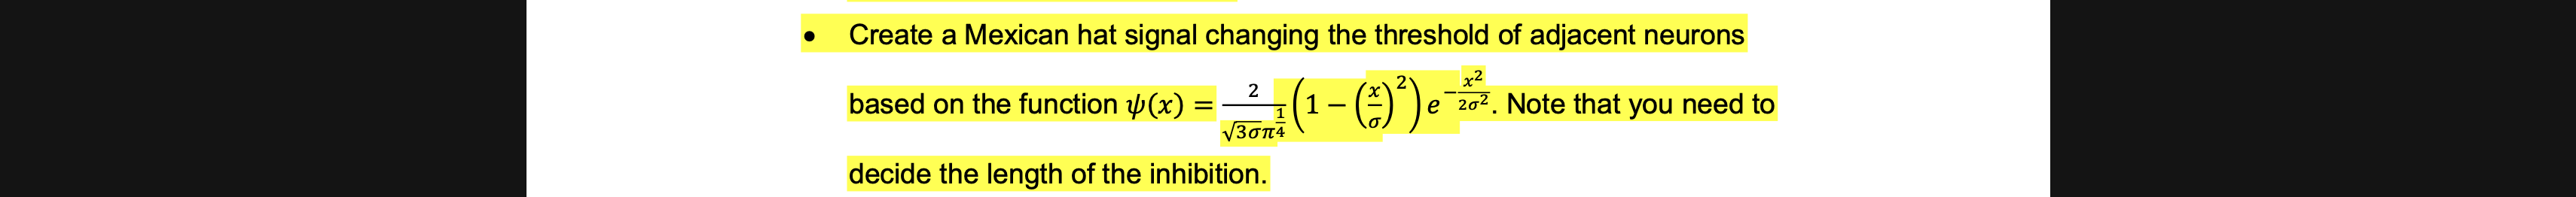

In [ ]:
x = np.abs(neurons - neurons[50]) # distance from the stimulated neuron
sd = 5 # standard deviation
k = 2 / (np.sqrt(3* sd) * np.power(np.pi,(1/4))) # Scaling factor of the mexican hat function
exponent = np.power(np.e, (-1* (np.power(x,2)/ (2* sd*sd))))
middle_component = 1 - (x/sd)**2
mexican_hat_function = k * middle_component * exponent

In [ ]:
plt.plot(mexican_hat_function)
plt.title("Mexican Hat Function")
plt.xlabel("Position of Neuron from pulse center")

## Define the threshold field

In [ ]:
initial_threshold = activation_threshold
inhibition_factor = -2 # this I found to be appropriate for lateral inhibition modelling
modified_threshold = initial_threshold + inhibition_factor * mexican_hat_function
'''if ainhibition factor is positive, then Threshold rises in regions where the mexican hat function is positive or not? does this make sense? '''
plt.plot(initial_threshold)
plt.plot(modified_threshold)
plt.legend(["Initial Threshold","Laterally inhibited threshold"],loc="upper left", fontsize = 7)
plt.title("Initial vs Modified Neuron Thresholds")
plt.ylabel("Voltage units")
plt.xlabel("Position of Neuron from pulse center")
plt.show()

## Firing Response

In [ ]:
factor = 0.5 # To control the scale factor 
firing_rate_stimulus = firing_rate_resting + factor * mexican_hat_function

In [ ]:
plt.plot(firing_rate_stimulus)
plt.title("Firing Rate after square pulse stimulus")
plt.ylabel("Firing rate")
plt.xlabel("Position of neurons from pulse center")

## Adding gaussian noise

In [ ]:
# This is additive noise, not multiplicative
gnoise = np.random.normal(0, 0.009, 100)
firing_rate_noised = firing_rate_stimulus + gnoise
plt.title("Firing Rate after adding noise")
plt.ylabel("Firing rate")
plt.xlabel("Position of neurons from pulse center")
plt.plot(firing_rate_noised)